In [3]:
!pip -q install librosa kaggle

In [4]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)

TensorFlow: 2.20.0
Librosa: 0.11.0


In [6]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"talha240657","key":"20f5647ab9f071174b84f712501667e8"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets list | head

ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                                 Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000          17527        405                1  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset    FIFA World Cup 2026 Player Performance Dataset         4154062  2026-06-10 12:58:47.093000           3859         81                1  
sharmajicoder/used-car-price-prediction-dataset                   Used Car Price Prediction Dataset                     51728243  2026-06-13 17:05:48.793000           2348         45          

In [9]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:20<00:00, 21.8MB/s]



In [10]:
!kaggle datasets download -d ejlok1/cremad

Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
100% 451M/451M [00:22<00:00, 20.9MB/s]



In [11]:
!unzip -q ravdess-emotional-speech-audio.zip -d RAVDESS
!unzip -q cremad.zip -d CREMAD

In [12]:
print(os.listdir("RAVDESS"))
print(os.listdir("CREMAD"))

['audio_speech_actors_01-24', 'Actor_16', 'Actor_08', 'Actor_15', 'Actor_23', 'Actor_24', 'Actor_05', 'Actor_06', 'Actor_10', 'Actor_04', 'Actor_11', 'Actor_19', 'Actor_20', 'Actor_22', 'Actor_14', 'Actor_12', 'Actor_09', 'Actor_18', 'Actor_01', 'Actor_03', 'Actor_07', 'Actor_02', 'Actor_13', 'Actor_17', 'Actor_21']
['AudioWAV']


In [13]:
ravdess_count = 0

for root, dirs, files in os.walk("RAVDESS"):
    for file in files:
        if file.endswith(".wav"):
            ravdess_count += 1

print("RAVDESS:", ravdess_count)

RAVDESS: 2880


In [14]:
crema_count = 0

for root, dirs, files in os.walk("CREMAD"):
    for file in files:
        if file.endswith(".wav"):
            crema_count += 1

print("CREMA-D:", crema_count)

CREMA-D: 7442


In [15]:
ravdess_emotions = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fear",
    "07": "Disgust",
    "08": "Surprised"
}

crema_emotions = {
    "ANG": "Angry",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad"
}

In [16]:
ravdess_data = []

for root, dirs, files in os.walk("RAVDESS"):
    for file in files:
        if file.endswith(".wav"):

            emotion_code = file.split("-")[2]

            emotion = ravdess_emotions[emotion_code]

            # Keep only speech recordings
            if emotion in ["Neutral","Happy","Sad","Angry","Fear","Disgust"]:

                ravdess_data.append([
                    os.path.join(root,file),
                    emotion,
                    "RAVDESS"
                ])

ravdess_df = pd.DataFrame(
    ravdess_data,
    columns=["Path","Emotion","Dataset"]
)

ravdess_df.head()

,Path,Emotion,Dataset
0,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Angry,RAVDESS
1,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Disgust,RAVDESS
2,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Fear,RAVDESS
3,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Fear,RAVDESS
4,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Disgust,RAVDESS


In [17]:
crema_data = []

for root, dirs, files in os.walk("CREMAD"):
    for file in files:
        if file.endswith(".wav"):

            emotion_code = file.split("_")[2]

            emotion = crema_emotions[emotion_code]

            crema_data.append([
                os.path.join(root,file),
                emotion,
                "CREMA-D"
            ])

crema_df = pd.DataFrame(
    crema_data,
    columns=["Path","Emotion","Dataset"]
)

crema_df.head()

,Path,Emotion,Dataset
0,CREMAD/AudioWAV/1066_MTI_NEU_XX.wav,Neutral,CREMA-D
1,CREMAD/AudioWAV/1052_ITH_ANG_XX.wav,Angry,CREMA-D
2,CREMAD/AudioWAV/1050_IWW_SAD_XX.wav,Sad,CREMA-D
3,CREMAD/AudioWAV/1007_TAI_ANG_XX.wav,Angry,CREMA-D
4,CREMAD/AudioWAV/1049_ITS_DIS_XX.wav,Disgust,CREMA-D


In [18]:
df = pd.concat([ravdess_df, crema_df], ignore_index=True)

print(df.shape)

df.head()

(9554, 3)


,Path,Emotion,Dataset
0,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Angry,RAVDESS
1,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Disgust,RAVDESS
2,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Fear,RAVDESS
3,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Fear,RAVDESS
4,RAVDESS/audio_speech_actors_01-24/Actor_16/03-...,Disgust,RAVDESS


In [19]:
df["Emotion"].value_counts()

,count
Emotion,
Angry,1655
Disgust,1655
Fear,1655
Happy,1655
Sad,1655
Neutral,1279


EDA

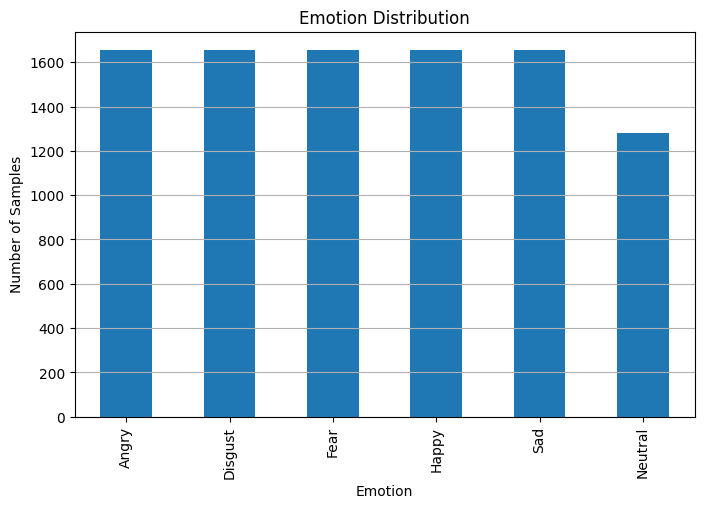

In [20]:
import matplotlib.pyplot as plt

emotion_counts = df["Emotion"].value_counts()

plt.figure(figsize=(8,5))
emotion_counts.plot(kind="bar")
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.grid(axis="y")
plt.show()

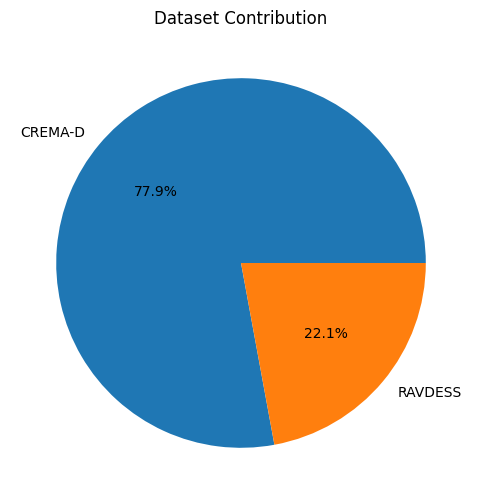

In [21]:
df["Dataset"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(6,6))
plt.title("Dataset Contribution")
plt.ylabel("")
plt.show()

In [22]:
sample_path = df.iloc[0]["Path"]

audio, sr = librosa.load(sample_path)

print("Sample Rate:", sr)
print("Duration:", len(audio)/sr, "seconds")

Sample Rate: 22050
Duration: 3.737097505668934 seconds


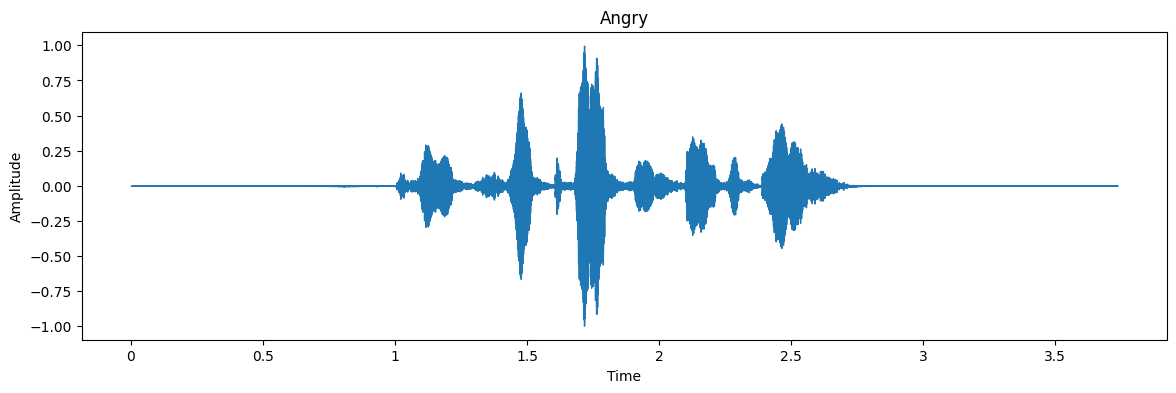

In [23]:
plt.figure(figsize=(14,4))
librosa.display.waveshow(audio, sr=sr)
plt.title(df.iloc[0]["Emotion"])
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

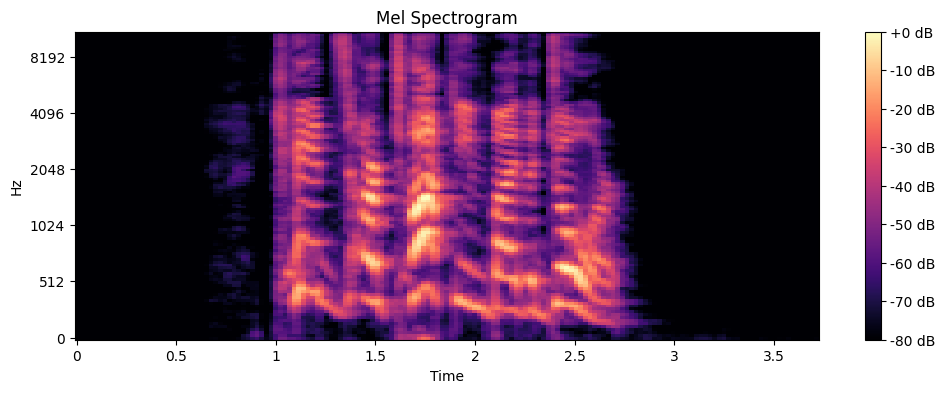

In [24]:
mel = librosa.feature.melspectrogram(y=audio, sr=sr)

mel_db = librosa.power_to_db(mel, ref=np.max)

plt.figure(figsize=(12,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.show()

Feature Extraction

In [37]:
TARGET_SR = 22050
DURATION = 3
TARGET_LENGTH = TARGET_SR * DURATION   # 66150 samples

In [38]:

def extract_features(path):

    # Load audio
    audio, sr = librosa.load(path, sr=TARGET_SR)

    # Pad or trim audio to exactly 3 seconds
    if len(audio) < TARGET_LENGTH:
        audio = np.pad(audio, (0, TARGET_LENGTH - len(audio)))
    else:
        audio = audio[:TARGET_LENGTH]

    # Feature extraction
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )
    mel = librosa.power_to_db(mel, ref=np.max)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=13
    )

    zcr = librosa.feature.zero_crossing_rate(audio)
    rms = librosa.feature.rms(y=audio)

    feature = np.vstack([mel, mfcc, zcr, rms])

    return feature

In [39]:
for i in [0, 100, 500, 1000, 5000]:
    feature = extract_features(df.iloc[i]["Path"])
    print(feature.shape)

(143, 130)
(143, 130)
(143, 130)
(143, 130)
(143, 130)


In [41]:
X = []
y = []

for path, emotion in tqdm(zip(df["Path"], df["Emotion"]),
                          total=len(df)):

    feature = extract_features(path)

    X.append(feature)
    y.append(emotion)

100%|██████████| 9554/9554 [05:31<00:00, 28.85it/s]


In [42]:
X = np.array(X, dtype=np.float32)
y = np.array(y)

print(X.shape)
print(y.shape)

(9554, 143, 130)
(9554,)


In [36]:
shapes = {}

for feature in X:
    shape = feature.shape
    shapes[shape] = shapes.get(shape, 0) + 1

print(shapes)

{(143, 130): 1955, (143, 128): 121, (143, 126): 91, (143, 127): 111, (143, 124): 98, (143, 123): 39, (143, 121): 101, (143, 120): 82, (143, 118): 98, (143, 113): 97, (143, 114): 104, (143, 117): 92, (143, 111): 79, (143, 115): 86, (143, 77): 368, (143, 94): 206, (143, 72): 193, (143, 92): 191, (143, 90): 191, (143, 91): 189, (143, 49): 30, (143, 103): 146, (143, 55): 70, (143, 58): 94, (143, 104): 131, (143, 75): 52, (143, 62): 123, (143, 87): 222, (143, 81): 193, (143, 105): 139, (143, 95): 175, (143, 74): 184, (143, 64): 108, (143, 82): 210, (143, 80): 223, (143, 85): 204, (143, 78): 182, (143, 65): 153, (143, 68): 162, (143, 97): 158, (143, 101): 161, (143, 71): 172, (143, 69): 150, (143, 59): 83, (143, 84): 226, (143, 100): 118, (143, 88): 206, (143, 61): 103, (143, 54): 44, (143, 67): 153, (143, 57): 85, (143, 108): 122, (143, 110): 85, (143, 98): 145, (143, 107): 110, (143, 52): 31, (143, 51): 32, (143, 47): 20, (143, 48): 20, (143, 44): 8, (143, 45): 11, (143, 36): 3, (143, 39):

Preparing the Data for CNN

In [43]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

print(encoder.classes_)

['Angry' 'Disgust' 'Fear' 'Happy' 'Neutral' 'Sad']


In [44]:
print(y[:10])

[0 1 2 2 1 2 2 3 2 0]


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [46]:
print(X_train.shape)
print(X_test.shape)

(7643, 143, 130)
(1911, 143, 130)


In [47]:
X_train_flat = X_train.reshape(-1, 143*130)

X_test_flat = X_test.reshape(-1, 143*130)

In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_flat = scaler.fit_transform(X_train_flat)

X_test_flat = scaler.transform(X_test_flat)

We flatten because StandardScaler works on 2D arrays

In [49]:
X_train = X_train_flat.reshape(-1,143,130)

X_test = X_test_flat.reshape(-1,143,130)

In [50]:
X_train = X_train[..., np.newaxis]

X_test = X_test[..., np.newaxis]

print(X_train.shape)
print(X_test.shape)

(7643, 143, 130, 1)
(1911, 143, 130, 1)


CNN

In [51]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

In [52]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(143,130,1)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.20),


    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.30),


    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.40),


    Flatten(),


    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.50),


    Dense(
        6,
        activation='softmax'
    )
])

In [53]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 143, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 143, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 71, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 71, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 71, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 35, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 35, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 34816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,456,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,550,918 (17.36 MB)

 Trainable params: 4,550,470 (17.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [54]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

In [56]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [58]:
print(np.isnan(X_train).sum())
print(np.isnan(X_test).sum())

0
0


In [59]:
print(X_train.min())
print(X_train.max())
print(X_train.mean())
print(X_train.std())

-11.651786
60.1273
4.501279e-09
1.0000006


In [60]:
print(np.unique(y_train, return_counts=True))

(array([0, 1, 2, 3, 4, 5]), array([1324, 1324, 1324, 1324, 1023, 1324]))


In [61]:
print(X_train.dtype)
print(y_train.dtype)

float32
int64


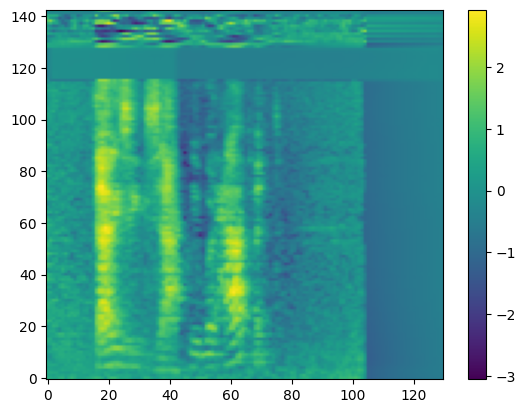

In [62]:
plt.imshow(X_train[0, :, :, 0], aspect='auto', origin='lower')
plt.colorbar()
plt.show()

In [63]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


In [64]:
np.save("X_features.npy", X)
np.save("y_labels.npy", y)

In [65]:
from google.colab import drive
drive.mount('/content/drive')

np.save('/content/drive/MyDrive/X_features.npy', X)
np.save('/content/drive/MyDrive/y_labels.npy', y)

Mounted at /content/drive


In [2]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np

X = np.load('/content/drive/MyDrive/X_features.npy')
y = np.load('/content/drive/MyDrive/y_labels.npy')

In [5]:
print(X.shape)
print(y.shape)

(9554, 143, 130)
(9554,)


In [7]:
print(np.unique(y))

[0 1 2 3 4 5]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

In [10]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape)

(7643, 143, 130, 1)


Better CNN

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(143,130,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu'),

    Dropout(0.4),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 143, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 143, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 71, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 71, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 71, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 35, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 35, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 35, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,214 (399.27 KB)

 Trainable params: 101,766 (397.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [15]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/30
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3207 - loss: 1.6147
Epoch 1: val_accuracy improved from None to 0.32636, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.3624 - loss: 1.5389 - val_accuracy: 0.3264 - val_loss: 1.5623 - learning_rate: 5.0000e-04
Epoch 2/30
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3988 - loss: 1.4613
Epoch 2: val_accuracy improved from 0.32636 to 0.34532, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.4060 - loss: 1.4405 - val_accuracy: 0.3453 - val_loss: 1.5292 - learning_rate: 5.0000e-04
Epoch 3/30
190/192 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4270 - loss: 1.4101
Epoch 3: val_accuracy improved from 0.34532 to 0.35710, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
192/192 ━━━━━━━━━━━━━━━━━━

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.6290 - loss: 1.0020
Test Accuracy : 0.6290
Test Loss     : 1.0020


In [17]:
import numpy as np

y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [19]:
emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad"
]

Classification Report

In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=emotion_labels
))

              precision    recall  f1-score   support

       Angry       0.79      0.77      0.78       331
     Disgust       0.73      0.47      0.57       331
        Fear       0.57      0.59      0.58       331
       Happy       0.58      0.66      0.62       331
     Neutral       0.54      0.71      0.62       256
         Sad       0.62      0.58      0.60       331

    accuracy                           0.63      1911
   macro avg       0.64      0.63      0.63      1911
weighted avg       0.64      0.63      0.63      1911



Confusion Matrix

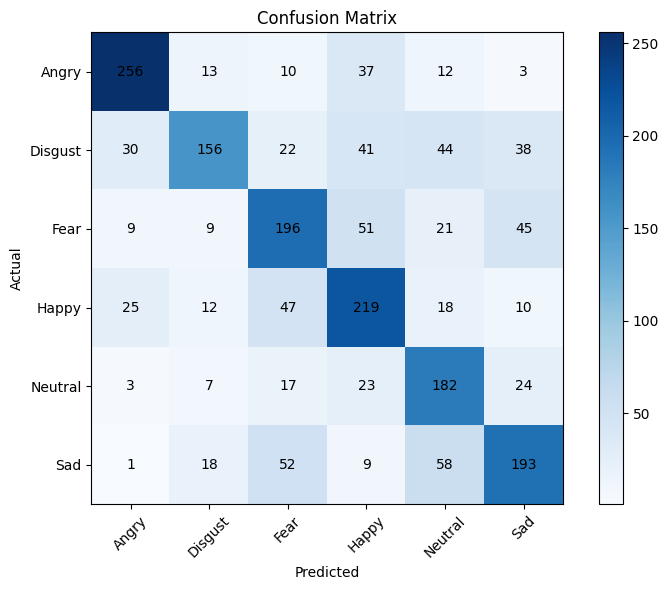

In [22]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")

plt.colorbar()

plt.xticks(np.arange(6), emotion_labels, rotation=45)
plt.yticks(np.arange(6), emotion_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]),
                 ha='center',
                 va='center',
                 color='black')

plt.tight_layout()
plt.show()

Accuracy Curve

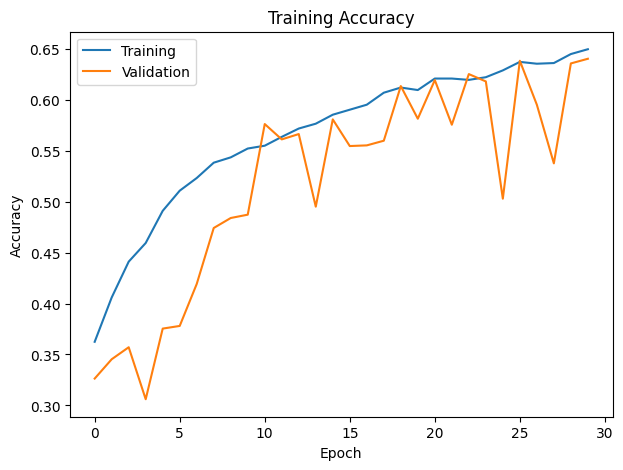

In [23]:
plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()

plt.show()

Loss Curve

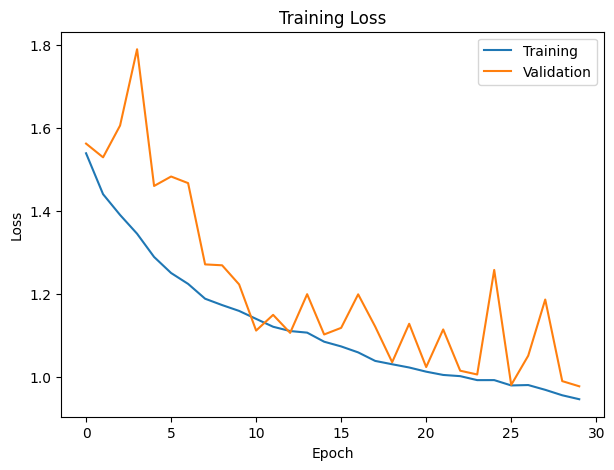

In [24]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()

plt.show()

In [25]:
model.save("speech_emotion_model.keras")

In [26]:
import pickle

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad"
]

with open("emotion_labels.pkl","wb") as f:
    pickle.dump(emotion_labels,f)